# Objectives

### English

- Validate manual name corrections to improve the Current Roster Matching pipeline.
- Identify players missing from the International Player Database.
- Expand the player database by reusing the Player Vector pipeline on compatible international competitions.
- Update the Current Roster Matching using the expanded player database.

### Español

- Validar las correcciones manuales de nombres para mejorar el Current Roster Matching.
- Identificar los jugadores ausentes de la International Player Database.
- Expandir la base de jugadores reutilizando el pipeline de Player Vectors sobre competiciones internacionales compatibles.
- Actualizar la cobertura de los planteles actuales mediante una versión expandida de la base de datos de jugadores.

# Configuration

## Imports

In [80]:
import pandas as pd
import numpy as np
import os
import re
import unicodedata
from pathlib import Path

## Paths

In [81]:
BASE_DIR = Path("..")

DATA_DIR = BASE_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
STATSBOMB_DATA_DIR = RAW_DIR / "statsbomb" / "data"

MATCHES_DIR = STATSBOMB_DATA_DIR / "matches"
LINEUPS_DIR = STATSBOMB_DATA_DIR / "lineups"

CURRENT_ROSTERS_PATH = RAW_DIR / "current_rosters" / "current_rosters_raw_v01.csv"

INTERNATIONAL_PLAYER_DATABASE_PATH = PROCESSED_DIR / "international_player_database_v01.csv"
UNMATCHED_PLAYERS_PATH = PROCESSED_DIR / "unmatched_roster_players_v01.csv"
PLAYER_DATABASE_NAMES_PATH = PROCESSED_DIR / "player_database_names_v01.csv"
NAME_CORRECTIONS_PATH = PROCESSED_DIR / "name_corrections_v01.csv"

CURRENT_ROSTER_MATCHING_V01_PATH = PROCESSED_DIR / "current_roster_matching_v01.csv"

INTERNATIONAL_PLAYER_DATABASE_V02_PATH = PROCESSED_DIR / "international_player_database_v02.csv"
INTERNATIONAL_PLAYER_VECTORS_MATCH_LEVEL_V02_PATH = PROCESSED_DIR / "international_player_vectors_match_level_v02.csv"
CURRENT_ROSTER_MATCHING_V02_PATH = PROCESSED_DIR / "current_roster_matching_v02.csv"

## Utility Functions

In [82]:
def normalize_name(name):
    """
    Normalize player names for matching.

    - Converts to lowercase.
    - Removes accents.
    - Removes punctuation.
    - Normalizes whitespace.
    """
    if pd.isna(name):
        return ""

    name = str(name).lower().strip()

    name = unicodedata.normalize("NFKD", name)
    name = "".join(char for char in name if not unicodedata.combining(char))

    name = re.sub(r"[^a-z0-9\s]", " ", name)
    name = re.sub(r"\s+", " ", name).strip()

    return name


In [83]:
def find_player(roster_name, roster_country, player_database):
    roster_name_normalized = normalize_name(roster_name)
    roster_tokens = set(roster_name_normalized.split())

    country_matches = player_database[
        player_database["team_name"] == roster_country
    ]

    # If country exists in database, search inside that country first.
    search_space = country_matches if len(country_matches) > 0 else player_database

    exact_matches = search_space[
        search_space["database_name_normalized"] == roster_name_normalized
    ]

    if len(exact_matches) == 1:
        return exact_matches.iloc[0], "exact_normalized_country"

    token_matches = search_space[
        search_space["database_name_normalized"].apply(
            lambda database_name: roster_tokens.issubset(set(database_name.split()))
        )
    ]

    if len(token_matches) == 1:
        return token_matches.iloc[0], "token_subset_country"

    return None, "unmatched"

In [84]:
def match_roster_players(current_rosters, player_database):
    matched_rows = []

    for _, roster_row in current_rosters.iterrows():
        match, match_method = find_player(
            roster_row["player_name"],
            roster_row["country_clean"],
            player_database
        )

        matched_rows.append({
            "country": roster_row["country"],
            "country_clean": roster_row["country_clean"],
            "roster_name": roster_row["player_name"],
            "position": roster_row["position"],
            "shirt_number": roster_row["shirt_number"],
            "player_id": match["player_id"] if match is not None else np.nan,
            "database_name": match["player_name"] if match is not None else np.nan,
            "database_team": match["team_name"] if match is not None else np.nan,
            "matched": match is not None,
            "match_method": match_method,
        })

    return pd.DataFrame(matched_rows)

In [85]:
def clean_roster_country(country):
    return re.sub(r"\s*\([A-Z]{3}\)$", "", country).strip()

In [86]:
def load_matches_for_competition(competition_id, season_id):
    matches_path = MATCHES_DIR / str(competition_id) / f"{season_id}.json"
    
    if not matches_path.exists():
        print(f"Missing matches file: {matches_path}")
        return pd.DataFrame()
    
    return pd.read_json(matches_path)

In [87]:
def load_lineup_players(match_id):
    lineup_path = LINEUPS_DIR / f"{match_id}.json"
    
    if not lineup_path.exists():
        return pd.DataFrame()
    
    lineup_data = pd.read_json(lineup_path)
    
    rows = []
    
    for _, team_row in lineup_data.iterrows():
        team_name = team_row["team_name"]
        
        for player in team_row["lineup"]:
            rows.append({
                "match_id": match_id,
                "team_name": team_name,
                "player_id": player.get("player_id"),
                "player_name": player.get("player_name"),
            })
    
    return pd.DataFrame(rows)

In [149]:
def token_set(name):
    return set(normalize_name(name).split())

In [150]:
def find_club_player_by_tokens(roster_name, club_players):
    roster_tokens = token_set(roster_name)

    matches = club_players[
        club_players["club_name_tokens"].apply(
            lambda club_tokens: roster_tokens.issubset(club_tokens)
            or club_tokens.issubset(roster_tokens)
        )
    ]

    if len(matches) == 0:
        return None
    
    return matches.iloc[0]

## Load Data

In [88]:
current_rosters = pd.read_csv(CURRENT_ROSTERS_PATH)
international_player_database = pd.read_csv(INTERNATIONAL_PLAYER_DATABASE_PATH)

unmatched_players = pd.read_csv(UNMATCHED_PLAYERS_PATH)
player_database_names = pd.read_csv(PLAYER_DATABASE_NAMES_PATH)
name_corrections = pd.read_csv(NAME_CORRECTIONS_PATH)

### Checks

In [89]:
datasets = {
    "current_rosters": current_rosters,
    "international_player_database": international_player_database,
    "unmatched_players": unmatched_players,
    "player_database_names": player_database_names,
    "name_corrections": name_corrections,
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

current_rosters: (1248, 4)
international_player_database: (2279, 32)
unmatched_players: (746, 4)
player_database_names: (2279, 3)
name_corrections: (75, 7)


In [90]:
for name, df in datasets.items():
    print(f"\n{name}")
    print(df.columns.tolist())


current_rosters
['country', 'player_name', 'position', 'shirt_number']

international_player_database
['player_id', 'player_name', 'team_name', 'matches_played', 'competitions_played', 'seasons_played', '50/50', 'Bad Behaviour', 'Ball Receipt*', 'Ball Recovery', 'Block', 'Carry', 'Clearance', 'Dispossessed', 'Dribble', 'Dribbled Past', 'Duel', 'Foul Committed', 'Foul Won', 'Goal Keeper', 'Interception', 'Miscontrol', 'Pass', 'Player Off', 'Player On', 'Pressure', 'Shield', 'Shot', 'Error', 'Offside', 'Own Goal Against', 'Camera On']

unmatched_players
['country', 'roster_name', 'position', 'shirt_number']

player_database_names
['player_id', 'player_name', 'team_name']

name_corrections
['country', 'roster_name', 'roster_name_normalized', 'database_name', 'database_name_normalized', 'correction_type', 'notes']


In [91]:
for name, df in datasets.items():
    print(f"\n{name}")
    print(df.isna().sum().sort_values(ascending=False).head(10))


current_rosters
country         0
player_name     0
position        0
shirt_number    0
dtype: int64

international_player_database
player_id              0
player_name            0
team_name              0
matches_played         0
competitions_played    0
seasons_played         0
50/50                  0
Bad Behaviour          0
Ball Receipt*          0
Ball Recovery          0
dtype: int64

unmatched_players
country         0
roster_name     0
position        0
shirt_number    0
dtype: int64

player_database_names
player_id      0
player_name    0
team_name      0
dtype: int64

name_corrections
country                     0
roster_name                 0
roster_name_normalized      0
database_name               0
database_name_normalized    0
correction_type             0
notes                       0
dtype: int64


In [92]:
for name, df in datasets.items():
    print(f"{name}: {df.duplicated().sum()} duplicated rows")

current_rosters: 0 duplicated rows
international_player_database: 0 duplicated rows
unmatched_players: 0 duplicated rows
player_database_names: 0 duplicated rows
name_corrections: 0 duplicated rows


In [93]:
for name, df in datasets.items():
    print(f"\n{name}")
    display(df.head())


current_rosters


,country,player_name,position,shirt_number
0,Algeria (ALG),MASTIL Melvin,Goalkeeper,1
1,Algeria (ALG),MANDI Aissa,Defender,2
2,Algeria (ALG),ABADA Achref,Defender,3
3,Algeria (ALG),TOUGAI Mohamed,Defender,4
4,Algeria (ALG),BELAID Zineddine,Defender,5



international_player_database


,player_id,player_name,team_name,matches_played,competitions_played,seasons_played,50/50,Bad Behaviour,Ball Receipt*,Ball Recovery,...,Pass,Player Off,Player On,Pressure,Shield,Shot,Error,Offside,Own Goal Against,Camera On
0,2941,Ismaïla Sarr,Senegal,11,2,3,3.0,0.0,378,31,...,213,1.0,1.0,183,0.0,20,0.0,1.0,0.0,0.0
1,2948,Nabil Fekir,France,6,1,1,0.0,0.0,59,9,...,40,0.0,0.0,32,0.0,4,0.0,0.0,0.0,0.0
2,2954,Youri Tielemans,Belgium,14,2,4,1.0,0.0,475,24,...,506,0.0,0.0,165,0.0,10,0.0,0.0,0.0,0.0
3,2956,Bertrand Isidore Traoré,Burkina Faso,4,1,1,0.0,0.0,98,7,...,69,1.0,1.0,13,0.0,11,0.0,0.0,0.0,0.0
4,2972,Marcus Thuram,France,10,2,3,1.0,0.0,193,14,...,104,0.0,0.0,73,1.0,14,0.0,0.0,0.0,0.0



unmatched_players


,country,roster_name,position,shirt_number
0,Algeria (ALG),MASTIL Melvin,Goalkeeper,1
1,Algeria (ALG),ABADA Achref,Defender,3
2,Algeria (ALG),BELAID Zineddine,Defender,5
3,Algeria (ALG),GOUIRI Amine,Forward,9
4,Algeria (ALG),HADJ MOUSSA,Forward,11



player_database_names


,player_id,player_name,team_name
0,2941,Ismaïla Sarr,Senegal
1,2948,Nabil Fekir,France
2,2954,Youri Tielemans,Belgium
3,2956,Bertrand Isidore Traoré,Burkina Faso
4,2972,Marcus Thuram,France



name_corrections


,country,roster_name,roster_name_normalized,database_name,database_name_normalized,correction_type,notes
0,Algeria (ALG),BOUDAOUI Hicham,boudaoui hicham,Hichem Boudaoui,hichem boudaoui,spelling/accent,manually proposed from roster/database country...
1,Argentina (ARG),GONZALEZ Nico,gonzalez nico,Nicolás Iván González,nicolas ivan gonzalez,nickname/full_name,manually proposed from roster/database country...
2,Austria (AUT),MWENE Phillip,mwene phillip,Philipp Mwene,philipp mwene,spelling,manually proposed from roster/database country...
3,Austria (AUT),SCHOEPF Alessandro,schoepf alessandro,Alessandro Schöpf,alessandro schopf,accent/transliteration,manually proposed from roster/database country...
4,Brazil (BRA),MARQUINHOS Marcos,marquinhos marcos,Marcos Aoás Corrêa,marcos aoas correa,nickname/full_name,manually proposed from roster/database country...


# Phase 1 - Manual Name Corrections

### Load and Validate Manual Corrections

In [94]:
print(f"Manual corrections: {len(name_corrections)}")

display(name_corrections["correction_type"].value_counts())

Manual corrections: 75


correction_type
nickname/full_name           17
short_name/full_name         13
romanization/order           11
spacing/full_name             6
spelling                      4
spelling/full_name            3
transliteration               3
transliteration/full_name     3
accent/order                  3
spelling/order                2
accent/full_name              2
spelling/accent               1
accent/transliteration        1
punctuation/accent            1
spelling/short_name           1
spacing/transliteration       1
spacing                       1
spelling/transliteration      1
order/full_name               1
Name: count, dtype: int64

In [95]:
display(
    name_corrections[
        ["country",
         "roster_name",
         "database_name",
         "correction_type"]
    ]
)

,country,roster_name,database_name,correction_type
0,Algeria (ALG),BOUDAOUI Hicham,Hichem Boudaoui,spelling/accent
1,Argentina (ARG),GONZALEZ Nico,Nicolás Iván González,nickname/full_name
2,Austria (AUT),MWENE Phillip,Philipp Mwene,spelling
3,Austria (AUT),SCHOEPF Alessandro,Alessandro Schöpf,accent/transliteration
4,Brazil (BRA),MARQUINHOS Marcos,Marcos Aoás Corrêa,nickname/full_name
...,...,...,...,...
70,Türkiye (TUR),YILMAZ Baris,Barış Alper Yılmaz,accent/full_name
71,Türkiye (TUR),CAKIR Ugurcan,Uğurcan Çakır,accent/order
72,USA (USA),TURNER Matt,Matthew Charles Turner,short_name/full_name
73,USA (USA),SCALLY Joe,Joseph Scally,short_name/full_name


In [96]:
assert name_corrections["roster_name"].is_unique
assert name_corrections["database_name"].notna().all()
assert name_corrections["country"].notna().all()

In [97]:
current_rosters_corrected = current_rosters.copy()

current_rosters_corrected = current_rosters_corrected.merge(
    name_corrections[
        ["country", "roster_name", "database_name"]
    ],
    how="left",
    left_on=["country", "player_name"],
    right_on=["country", "roster_name"]
)

In [98]:
current_rosters_corrected["player_name"] = (
    current_rosters_corrected["database_name"]
    .fillna(current_rosters_corrected["player_name"])
)

In [99]:
applied_corrections = current_rosters_corrected["database_name"].notna().sum()

print(f"Manual corrections applied: {applied_corrections}")

Manual corrections applied: 75


In [100]:
current_rosters_corrected.drop(
    columns=["roster_name", "database_name"],
    inplace=True
)

### Verify Applied Corrections

In [101]:
changed_players = (
    current_rosters["player_name"] !=
    current_rosters_corrected["player_name"]
)

print(f"Players renamed: {changed_players.sum()}")

Players renamed: 75


In [102]:
display(
    pd.DataFrame({
        "original_name": current_rosters.loc[changed_players, "player_name"],
        "corrected_name": current_rosters_corrected.loc[changed_players, "player_name"],
        "country": current_rosters.loc[changed_players, "country"]
    }).reset_index(drop=True)
)

,original_name,corrected_name,country
0,BOUDAOUI Hicham,Hichem Boudaoui,Algeria (ALG)
1,GONZALEZ Nico,Nicolás Iván González,Argentina (ARG)
2,MWENE Phillip,Philipp Mwene,Austria (AUT)
3,SCHOEPF Alessandro,Alessandro Schöpf,Austria (AUT)
4,MARQUINHOS Marcos,Marcos Aoás Corrêa,Brazil (BRA)
...,...,...,...
70,YILMAZ Baris,Barış Alper Yılmaz,Türkiye (TUR)
71,CAKIR Ugurcan,Uğurcan Çakır,Türkiye (TUR)
72,TURNER Matt,Matthew Charles Turner,USA (USA)
73,SCALLY Joe,Joseph Scally,USA (USA)


### Rebuild

In [103]:
current_rosters_corrected["country_clean"] = (
    current_rosters_corrected["country"]
    .apply(clean_roster_country)
)

In [104]:
international_player_database["database_name_normalized"] = (
    international_player_database["player_name"]
    .apply(normalize_name)
)

In [105]:
current_roster_matching_v01 = match_roster_players(
    current_rosters_corrected,
    international_player_database
)

In [106]:
matched_count = current_roster_matching_v01["matched"].sum()
total_players = len(current_roster_matching_v01)
coverage = matched_count / total_players

print(f"Matched players: {matched_count}/{total_players}")
print(f"Coverage: {coverage:.2%}")

Matched players: 577/1248
Coverage: 46.23%


In [107]:
current_roster_matching_v01["match_method"].value_counts(dropna=False)

match_method
unmatched                   671
token_subset_country        491
exact_normalized_country     86
Name: count, dtype: int64

In [108]:
display(current_roster_matching_v01.head())

,country,country_clean,roster_name,position,shirt_number,player_id,database_name,database_team,matched,match_method
0,Algeria (ALG),Algeria,MASTIL Melvin,Goalkeeper,1,NaN,NaN,NaN,False,unmatched
1,Algeria (ALG),Algeria,MANDI Aissa,Defender,2,6648.0,Aïssa Mandi,Algeria,True,token_subset_country
2,Algeria (ALG),Algeria,ABADA Achref,Defender,3,NaN,NaN,NaN,False,unmatched
3,Algeria (ALG),Algeria,TOUGAI Mohamed,Defender,4,160943.0,Mohamed Amine Tougai,Algeria,True,token_subset_country
4,Algeria (ALG),Algeria,BELAID Zineddine,Defender,5,NaN,NaN,NaN,False,unmatched


### Save Checkpoint

In [109]:
current_roster_matching_v01.to_csv(
    CURRENT_ROSTER_MATCHING_V01_PATH,
    index=False
)

print(f"Saved to: {CURRENT_ROSTER_MATCHING_V01_PATH}")

Saved to: ..\data\processed\current_roster_matching_v01.csv


### Coverage Analysis

In [110]:
coverage_by_country_v01 = (
    current_roster_matching_v01
    .groupby("country")
    .agg(
        total_players=("roster_name", "count"),
        matched_players=("matched", "sum")
    )
    .reset_index()
)

coverage_by_country_v01["unmatched_players"] = (
    coverage_by_country_v01["total_players"] -
    coverage_by_country_v01["matched_players"]
)

coverage_by_country_v01["coverage"] = (
    coverage_by_country_v01["matched_players"] /
    coverage_by_country_v01["total_players"]
)

coverage_by_country_v01 = coverage_by_country_v01.sort_values(
    "coverage",
    ascending=True
)

display(coverage_by_country_v01)

,country,total_players,matched_players,unmatched_players,coverage
5,Bosnia And Herzegovina (BIH),26,0,26,0.000000
12,Curaçao (CUW),26,0,26,0.000000
21,Haiti (HAI),26,0,26,0.000000
30,New Zealand (NZL),26,0,26,0.000000
25,Jordan (JOR),26,0,26,0.000000
31,Norway (NOR),26,0,26,0.000000
23,Iraq (IRQ),26,0,26,0.000000
47,Uzbekistan (UZB),26,0,26,0.000000
41,Sweden (SWE),26,2,24,0.076923
43,Tunisia (TUN),26,8,18,0.307692


In [111]:
coverage_by_country_v01.describe()

,total_players,matched_players,unmatched_players,coverage
count,48.0,48.000000,48.000000,48.000000
mean,26.0,12.020833,13.979167,0.462340
std,0.0,6.586542,6.586542,0.253329
min,26.0,0.000000,5.000000,0.000000
25%,26.0,8.750000,9.000000,0.336538
50%,26.0,14.500000,11.500000,0.557692
75%,26.0,17.000000,17.250000,0.653846
max,26.0,21.000000,26.000000,0.807692


In [112]:
display(coverage_by_country_v01.head(10))

,country,total_players,matched_players,unmatched_players,coverage
5,Bosnia And Herzegovina (BIH),26,0,26,0.000000
12,Curaçao (CUW),26,0,26,0.000000
21,Haiti (HAI),26,0,26,0.000000
30,New Zealand (NZL),26,0,26,0.000000
25,Jordan (JOR),26,0,26,0.000000
31,Norway (NOR),26,0,26,0.000000
23,Iraq (IRQ),26,0,26,0.000000
47,Uzbekistan (UZB),26,0,26,0.000000
41,Sweden (SWE),26,2,24,0.076923
43,Tunisia (TUN),26,8,18,0.307692


In [113]:
new_unmatched_players_v01 = (
    current_roster_matching_v01[
        ~current_roster_matching_v01["matched"]
    ]
    .copy()
)

print(f"Unmatched players after manual corrections: {len(new_unmatched_players_v01)}")

display(new_unmatched_players_v01.head())

Unmatched players after manual corrections: 671


,country,country_clean,roster_name,position,shirt_number,player_id,database_name,database_team,matched,match_method
0,Algeria (ALG),Algeria,MASTIL Melvin,Goalkeeper,1,NaN,NaN,NaN,False,unmatched
2,Algeria (ALG),Algeria,ABADA Achref,Defender,3,NaN,NaN,NaN,False,unmatched
4,Algeria (ALG),Algeria,BELAID Zineddine,Defender,5,NaN,NaN,NaN,False,unmatched
8,Algeria (ALG),Algeria,GOUIRI Amine,Forward,9,NaN,NaN,NaN,False,unmatched
10,Algeria (ALG),Algeria,HADJ MOUSSA,Forward,11,NaN,NaN,NaN,False,unmatched


<Axes: xlabel='country'>

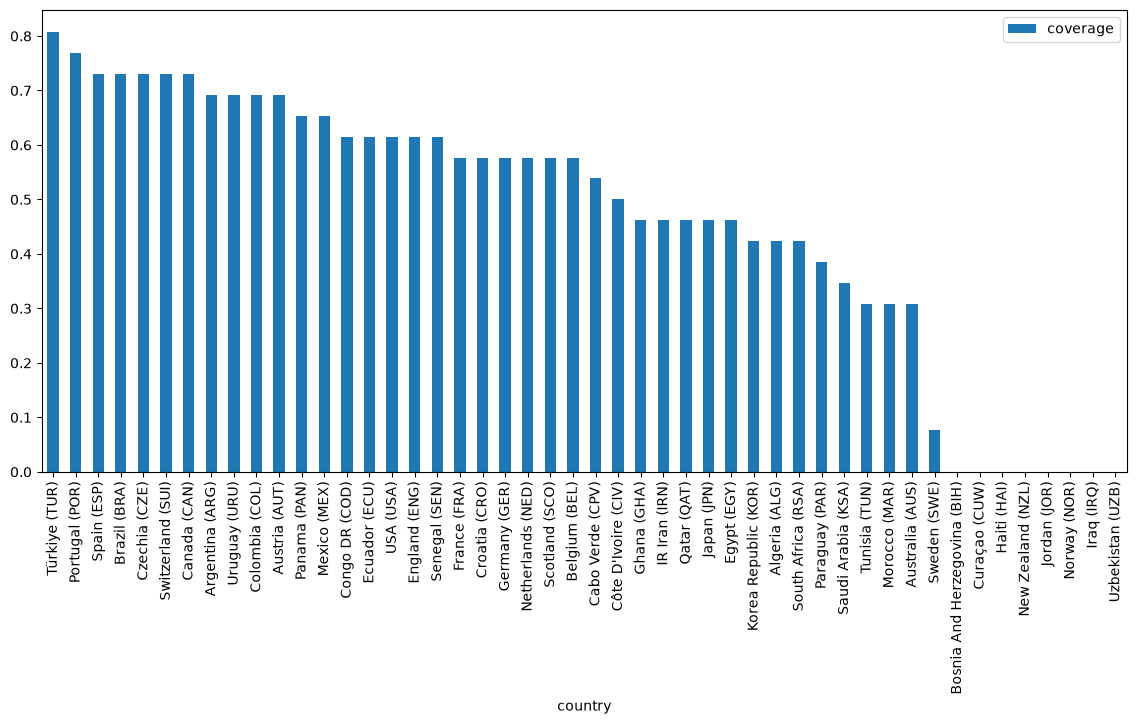

In [114]:
coverage_by_country_v01.sort_values(
    "coverage",
    ascending=False
).plot.bar(
    x="country",
    y="coverage",
    figsize=(14,6)
)

## Remaining Unmatched Players Analysis

### Summary

In [115]:
remaining_unmatched = current_roster_matching_v01[
    ~current_roster_matching_v01["matched"]
].copy()

print(f"Remaining unmatched players: {len(remaining_unmatched)}")
print(f"Remaining coverage: {len(remaining_unmatched)/len(current_roster_matching_v01):.2%}")

Remaining unmatched players: 671
Remaining coverage: 53.77%


### Remaining by country

In [116]:
remaining_by_country = (
    remaining_unmatched
    .groupby("country")
    .agg(
        unmatched_players=("roster_name", "count")
    )
    .sort_values("unmatched_players", ascending=False)
    .reset_index()
)

display(remaining_by_country)

,country,unmatched_players
0,Bosnia And Herzegovina (BIH),26
1,Curaçao (CUW),26
2,Uzbekistan (UZB),26
3,New Zealand (NZL),26
4,Jordan (JOR),26
5,Norway (NOR),26
6,Haiti (HAI),26
7,Iraq (IRQ),26
8,Sweden (SWE),24
9,Morocco (MAR),18


### Join with coverage

In [117]:
remaining_summary = coverage_by_country_v01.merge(
    remaining_by_country,
    on="country",
    how="left",
    suffixes=("", "_check")
)

remaining_summary.drop(
    columns=["unmatched_players_check"],
    inplace=True
)

display(remaining_summary)

,country,total_players,matched_players,unmatched_players,coverage
0,Bosnia And Herzegovina (BIH),26,0,26,0.000000
1,Curaçao (CUW),26,0,26,0.000000
2,Haiti (HAI),26,0,26,0.000000
3,New Zealand (NZL),26,0,26,0.000000
4,Jordan (JOR),26,0,26,0.000000
5,Norway (NOR),26,0,26,0.000000
6,Iraq (IRQ),26,0,26,0.000000
7,Uzbekistan (UZB),26,0,26,0.000000
8,Sweden (SWE),26,2,24,0.076923
9,Tunisia (TUN),26,8,18,0.307692


### Export

In [118]:
remaining_unmatched.to_csv(
    PROCESSED_DIR / "remaining_unmatched_players_v01.csv",
    index=False
)

### Discussion

Manual name corrections increased roster coverage from approximately 40% to 46%.

The remaining unmatched players are not uniformly distributed across national teams. Several countries have no representation in the current International Player Database, while others already exhibit moderate to high coverage.

The next step is not to immediately expand the database, but to determine whether these remaining players already exist in other international competitions available in StatsBomb Open Data. Only after that analysis will additional competitions be incorporated into the player database.

# Phase 2 — Player Database Expansion

## Identify Priority Countries

In [119]:
priority_countries = remaining_summary[
    remaining_summary["coverage"] < 0.50
].copy()

display(priority_countries)

,country,total_players,matched_players,unmatched_players,coverage
0,Bosnia And Herzegovina (BIH),26,0,26,0.000000
1,Curaçao (CUW),26,0,26,0.000000
2,Haiti (HAI),26,0,26,0.000000
3,New Zealand (NZL),26,0,26,0.000000
4,Jordan (JOR),26,0,26,0.000000
5,Norway (NOR),26,0,26,0.000000
6,Iraq (IRQ),26,0,26,0.000000
7,Uzbekistan (UZB),26,0,26,0.000000
8,Sweden (SWE),26,2,24,0.076923
9,Tunisia (TUN),26,8,18,0.307692


## International Competitions Assessment

### Load Competition Inventory (Notebook 11)

In [120]:
competitions_path = STATSBOMB_DATA_DIR / "competitions.json"

competitions = pd.read_json(competitions_path)

competitions.head()

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-11-15T23:17:41.827093,2025-11-15T23:17:41.827093,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,NaN,NaN,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2026-05-12T21:18:08.827431,2026-05-02T02:07:18.902396,2026-05-02T02:07:18.902396,2026-05-12T21:18:08.827431
3,16,4,Europe,Champions League,male,False,False,2018/2019,2026-05-15T15:54:04.598614,2021-06-13T16:17:31.694,NaN,2026-05-15T15:54:04.598614
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,NaN,2024-02-13T02:35:28.134882


In [121]:
competition_cols = [
    "competition_id",
    "season_id",
    "country_name",
    "competition_name",
    "competition_gender",
    "competition_youth",
    "competition_international",
    "season_name",
    "match_available",
    "match_available_360",
    "match_updated",
    "match_updated_360",
]

available_cols = [col for col in competition_cols if col in competitions.columns]

competitions_clean = competitions[available_cols].copy()

competitions_clean.head()

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_available,match_available_360,match_updated,match_updated_360
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-11-15T23:17:41.827093,2024-09-28T20:46:38.893391,2025-11-15T23:17:41.827093
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,NaN,2024-05-19T11:11:14.192381,NaN
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2026-05-12T21:18:08.827431,2026-05-02T02:07:18.902396,2026-05-12T21:18:08.827431,2026-05-02T02:07:18.902396
3,16,4,Europe,Champions League,male,False,False,2018/2019,2026-05-15T15:54:04.598614,NaN,2026-05-15T15:54:04.598614,2021-06-13T16:17:31.694
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,NaN,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694


### Available Senior International Competitions

In [122]:
international_competitions = competitions_clean[
    (competitions_clean["competition_gender"] == "male") &
    (competitions_clean["competition_international"] == True) &
    (competitions_clean["competition_youth"] == False)
].copy()

display(
    international_competitions[
        [
            "competition_id",
            "season_id",
            "country_name",
            "competition_name",
            "season_name",
        ]
    ].sort_values(
        ["competition_name", "season_name"]
    )
)

,competition_id,season_id,country_name,competition_name,season_name
2,1267,107,Africa,African Cup of Nations,2023
21,223,282,South America,Copa America,2024
37,43,269,International,FIFA World Cup,1958
36,43,270,International,FIFA World Cup,1962
35,43,272,International,FIFA World Cup,1970
34,43,51,International,FIFA World Cup,1974
33,43,54,International,FIFA World Cup,1986
32,43,55,International,FIFA World Cup,1990
31,43,3,International,FIFA World Cup,2018
30,43,106,International,FIFA World Cup,2022


### International Competitions Already Included

In [123]:
used_competitions = [
    ("African Cup of Nations", "2023"),
    ("Copa America", "2024"),
    ("FIFA World Cup", "2018"),
    ("FIFA World Cup", "2022"),
    ("UEFA Euro", "2020"),
    ("UEFA Euro", "2024"),
]

In [124]:
international_competitions["already_used"] = (
    international_competitions.apply(
        lambda row: (
            row["competition_name"],
            str(row["season_name"])
        ) in used_competitions,
        axis=1
    )
)

In [125]:
display(
    international_competitions[
        [
            "competition_name",
            "season_name",
            "already_used"
        ]
    ]
)

,competition_name,season_name,already_used
2,African Cup of Nations,2023,True
21,Copa America,2024,True
30,FIFA World Cup,2022,True
31,FIFA World Cup,2018,True
32,FIFA World Cup,1990,False
33,FIFA World Cup,1986,False
34,FIFA World Cup,1974,False
35,FIFA World Cup,1970,False
36,FIFA World Cup,1962,False
37,FIFA World Cup,1958,False


In [126]:
print(competitions.shape)

print(competitions["competition_name"].nunique())

print(sorted(competitions["competition_name"].unique()))

(80, 12)
24
['1. Bundesliga', 'African Cup of Nations', 'Champions League', 'Copa America', 'Copa del Rey', "FA Women's Super League", 'FIFA U20 World Cup', 'FIFA World Cup', 'Frauen Bundesliga', 'Indian Super league', 'La Liga', 'Liga F', 'Liga Profesional', 'Ligue 1', 'Major League Soccer', 'NWSL', 'North American League', 'Premier League', 'Serie A', 'Serie A Women', 'UEFA Euro', 'UEFA Europa League', "UEFA Women's Euro", "Women's World Cup"]


### Competition Coverage Assessment

The remaining unmatched players were compared against the available senior men's international competitions in StatsBomb Open Data.

The inventory confirms that the International Player Database V01 already includes all recent senior men's international competitions currently available in the local StatsBomb Open Data source:

- FIFA World Cup 2018
- FIFA World Cup 2022
- UEFA Euro 2020
- UEFA Euro 2024
- Copa America 2024
- African Cup of Nations 2023

Additional competitions that would be useful for several low-coverage teams, such as the AFC Asian Cup, CONCACAF Gold Cup, UEFA Nations League, and OFC competitions, are not available in the current open dataset.

Manual checks for well-known players from low-coverage European teams also confirmed that players such as Haaland, Ødegaard, Isak, and Gyökeres are absent from the current player database.

Therefore, the remaining unmatched players should be interpreted primarily as a data coverage limitation rather than a matching failure.

## Club Competition Assessment

### Available Club Competitions

In [127]:
candidate_club_competitions = competitions_clean[
    (competitions_clean["competition_gender"] == "male") &
    (competitions_clean["competition_youth"] == False) &
    (competitions_clean["competition_international"] == False)
].copy()

candidate_club_competitions[
    ["competition_id", "season_id", "country_name", "competition_name", "season_name"]
].sort_values(["competition_name", "season_name"])


,competition_id,season_id,country_name,competition_name,season_name
1,9,27,Germany,1. Bundesliga,2015/2016
0,9,281,Germany,1. Bundesliga,2023/2024
20,16,276,Europe,Champions League,1970/1971
19,16,71,Europe,Champions League,1971/1972
18,16,277,Europe,Champions League,1972/1973
17,16,76,Europe,Champions League,1999/2000
16,16,44,Europe,Champions League,2003/2004
15,16,37,Europe,Champions League,2004/2005
14,16,39,Europe,Champions League,2006/2007
13,16,41,Europe,Champions League,2008/2009


### Candidate Competitions

In [128]:
selected_club_competitions = [
    "Champions League",
    "UEFA Europa League",
    "Premier League",
    "La Liga",
    "Serie A",
    "Ligue 1",
    "1. Bundesliga",
    "Major League Soccer",
    "Liga Profesional",
]

In [129]:
club_candidates = candidate_club_competitions[
    candidate_club_competitions["competition_name"].isin(selected_club_competitions)
].copy()

club_candidates_display = (
    club_candidates[
        [
            "competition_id",
            "season_id",
            "country_name",
            "competition_name",
            "season_name",
            "match_available",
        ]
    ]
    .sort_values(["competition_name", "season_name"])
)

display(club_candidates_display)

,competition_id,season_id,country_name,competition_name,season_name,match_available
1,9,27,Germany,1. Bundesliga,2015/2016,2024-05-19T11:11:14.192381
0,9,281,Germany,1. Bundesliga,2023/2024,2024-09-28T20:46:38.893391
20,16,276,Europe,Champions League,1970/1971,2024-02-13T14:24:12.213582
19,16,71,Europe,Champions League,1971/1972,2024-02-12T14:25:01.735880
18,16,277,Europe,Champions League,1972/1973,2024-02-13T14:25:16.532771
17,16,76,Europe,Champions League,1999/2000,2025-06-23T12:34:36.649637
16,16,44,Europe,Champions League,2003/2004,2025-06-24T13:57:37.321382
15,16,37,Europe,Champions League,2004/2005,2025-06-24T09:44:09.039471
14,16,39,Europe,Champions League,2006/2007,2024-02-12T13:48:23.967222
13,16,41,Europe,Champions League,2008/2009,2024-02-13T07:02:54.657056


In [130]:
club_candidates_summary = (
    club_candidates
    .groupby("competition_name")
    .agg(
        seasons_available=("season_name", "nunique"),
        first_season=("season_name", "min"),
        last_season=("season_name", "max"),
    )
    .reset_index()
    .sort_values("competition_name")
)

display(club_candidates_summary)

,competition_name,seasons_available,first_season,last_season
0,1. Bundesliga,2,2015/2016,2023/2024
1,Champions League,18,1970/1971,2018/2019
2,La Liga,18,1973/1974,2020/2021
3,Liga Profesional,2,1981,1997/1998
4,Ligue 1,3,2015/2016,2022/2023
5,Major League Soccer,1,2023,2023
6,Premier League,2,2003/2004,2015/2016
7,Serie A,2,1986/1987,2015/2016
8,UEFA Europa League,1,1988/1989,1988/1989


In [131]:
selected_club_competition_seasons = [
    ("1. Bundesliga", "2023/2024"),
    ("Ligue 1", "2022/2023"),
    ("Major League Soccer", "2023"),
    ("La Liga", "2020/2021"),
    ("La Liga", "2019/2020"),
    ("La Liga", "2018/2019"),
    ("Champions League", "2018/2019"),
]

selected_club_competitions_df = club_candidates[
    club_candidates.apply(
        lambda row: (
            row["competition_name"],
            str(row["season_name"])
        ) in selected_club_competition_seasons,
        axis=1
    )
].copy()

display(
    selected_club_competitions_df[
        [
            "competition_id",
            "season_id",
            "country_name",
            "competition_name",
            "season_name",
            "match_available",
        ]
    ].sort_values(["competition_name", "season_name"])
)

,competition_id,season_id,country_name,competition_name,season_name,match_available
0,9,281,Germany,1. Bundesliga,2023/2024,2024-09-28T20:46:38.893391
3,16,4,Europe,Champions League,2018/2019,2026-05-15T15:54:04.598614
42,11,4,Spain,La Liga,2018/2019,2026-04-06T04:49:09.959011
41,11,42,Spain,La Liga,2019/2020,2024-12-16T16:51:06.833054
40,11,90,Spain,La Liga,2020/2021,2025-11-02T03:55:19.577958
61,7,235,France,Ligue 1,2022/2023,2026-04-06T18:51:07.770289
64,44,107,United States of America,Major League Soccer,2023,2026-02-05T12:10:54.420133


### Coverage Experiment

#### Load Selected Matches

In [132]:
selected_matches = []

for _, row in selected_club_competitions_df.iterrows():
    matches = load_matches_for_competition(
        row["competition_id"],
        row["season_id"]
    )

    if len(matches) > 0:
        matches["competition_id"] = row["competition_id"]
        matches["season_id"] = row["season_id"]
        matches["competition_name"] = row["competition_name"]
        matches["season_name"] = row["season_name"]
        
        selected_matches.append(matches)

    selected_matches_df = pd.concat(selected_matches, ignore_index=True)

print(f"Selected matches: {selected_matches_df.shape}")
display(selected_matches_df.head())

Selected matches: (175, 22)


,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,...,last_updated_360,metadata,match_week,competition_stage,stadium,referee,competition_id,season_id,competition_name,season_name
0,3895292,2024-04-06,15:30:00.000,"{'competition_id': 9, 'country_name': 'Germany...","{'season_id': 281, 'season_name': '2023/2024'}","{'home_team_id': 190, 'home_team_name': 'Union...","{'away_team_id': 904, 'away_team_name': 'Bayer...",0,1,available,...,2025-07-06T04:26:07.636270,"{'data_version': '1.1.0', 'shot_fidelity_versi...",28,"{'id': 1, 'name': 'Regular Season'}","{'id': 560, 'name': 'Stadion An der Alten Förs...","{'id': 235, 'name': 'Benjamin Brand', 'country...",9,281,1. Bundesliga,2023/2024
1,3895320,2024-04-27,19:30:00.000,"{'competition_id': 9, 'country_name': 'Germany...","{'season_id': 281, 'season_name': '2023/2024'}","{'home_team_id': 904, 'home_team_name': 'Bayer...","{'away_team_id': 174, 'away_team_name': 'VfB S...",2,2,available,...,2025-01-02T11:05:23.462823,"{'data_version': '1.1.0', 'shot_fidelity_versi...",31,"{'id': 1, 'name': 'Regular Season'}","{'id': 377, 'name': 'BayArena', 'country': {'i...","{'id': 241, 'name': 'Felix Zwayer', 'country':...",9,281,1. Bundesliga,2023/2024
2,3895158,2023-12-03,18:30:00.000,"{'competition_id': 9, 'country_name': 'Germany...","{'season_id': 281, 'season_name': '2023/2024'}","{'home_team_id': 904, 'home_team_name': 'Bayer...","{'away_team_id': 180, 'away_team_name': 'Borus...",1,1,available,...,2025-09-07T09:35:11.061799,"{'data_version': '1.1.0', 'shot_fidelity_versi...",13,"{'id': 1, 'name': 'Regular Season'}","{'id': 377, 'name': 'BayArena', 'country': {'i...","{'id': 225, 'name': 'Daniel Siebert', 'country...",9,281,1. Bundesliga,2023/2024
3,3895107,2023-10-08,16:30:00.000,"{'competition_id': 9, 'country_name': 'Germany...","{'season_id': 281, 'season_name': '2023/2024'}","{'home_team_id': 904, 'home_team_name': 'Bayer...","{'away_team_id': 186, 'away_team_name': 'FC Kö...",3,0,available,...,2024-10-14T10:35:11.461679,"{'data_version': '1.1.0', 'shot_fidelity_versi...",7,"{'id': 1, 'name': 'Regular Season'}","{'id': 377, 'name': 'BayArena', 'country': {'i...","{'id': 241, 'name': 'Felix Zwayer', 'country':...",9,281,1. Bundesliga,2023/2024
4,3895340,2024-05-12,20:30:00.000,"{'competition_id': 9, 'country_name': 'Germany...","{'season_id': 281, 'season_name': '2023/2024'}","{'home_team_id': 868, 'home_team_name': 'Bochu...","{'away_team_id': 904, 'away_team_name': 'Bayer...",0,5,available,...,2025-01-01T12:14:22.212709,"{'data_version': '1.1.0', 'shot_fidelity_versi...",33,"{'id': 1, 'name': 'Regular Season'}","{'id': 550, 'name': 'Vonovia Ruhrstadion', 'co...","{'id': 235, 'name': 'Benjamin Brand', 'country...",9,281,1. Bundesliga,2023/2024


In [133]:
# Refactor
selected_matches = selected_matches_df

#### Load Available Players

In [134]:
club_lineup_players = []

for match_id in selected_matches["match_id"].unique():
    players = load_lineup_players(match_id)
    
    if len(players) > 0:
        club_lineup_players.append(players)

club_lineup_players = pd.concat(club_lineup_players, ignore_index=True)

club_lineup_players = club_lineup_players.drop_duplicates(
    subset=["player_id", "player_name", "team_name"]
)

print(f"Club lineup players: {club_lineup_players.shape}")
display(club_lineup_players.head())

Club lineup players: (2113, 4)


,match_id,team_name,player_id,player_name
0,3895292,Union Berlin,3117,Lucas Tousart
1,3895292,Union Berlin,6985,Robin Gosens
2,3895292,Union Berlin,8239,Robin Knoche
3,3895292,Union Berlin,8397,Kevin Vogt
4,3895292,Union Berlin,8933,Alexander Schwolow


#### Normalize

In [135]:
remaining_unmatched["roster_name_normalized"] = (
    remaining_unmatched["roster_name"].apply(normalize_name)
)

club_lineup_players["club_player_name_normalized"] = (
    club_lineup_players["player_name"].apply(normalize_name)
)

### Token-Based Club Coverage Matching

This step compares the remaining unmatched roster players against players found in selected club competition lineups.

Since roster names and club data names may use different name ordering or full-name conventions, exact string matching is not sufficient. A token-based matching strategy is used instead.

#### Build Token-Based Matching

In [151]:
club_lineup_players["club_name_tokens"] = (
    club_lineup_players["player_name"].apply(token_set)
)

remaining_unmatched["roster_name_tokens"] = (
    remaining_unmatched["roster_name"].apply(token_set)
)

In [152]:
coverage_rows = []

for _, row in remaining_unmatched.iterrows():
    match = find_club_player_by_tokens(
        row["roster_name"],
        club_lineup_players
    )

    coverage_rows.append({
        "country": row["country"],
        "roster_name": row["roster_name"],
        "position": row["position"],
        "shirt_number": row["shirt_number"],
        "found_in_club_data": match is not None,
        "club_player_id": match["player_id"] if match is not None else np.nan,
        "club_player_name": match["player_name"] if match is not None else np.nan,
        "club_team_name": match["team_name"] if match is not None else np.nan,
    })

club_coverage_candidates = pd.DataFrame(coverage_rows)

#### Coverage Result

In [153]:
found_count = club_coverage_candidates["found_in_club_data"].sum()
total_remaining = len(club_coverage_candidates)

print(f"Remaining unmatched players found in selected club data: {found_count}/{total_remaining}")
print(f"Potential additional coverage: {found_count / total_remaining:.2%}")

Remaining unmatched players found in selected club data: 57/671
Potential additional coverage: 8.49%


#### Matched Players Preview

In [154]:
display(
    club_coverage_candidates[
        club_coverage_candidates["found_in_club_data"]
    ].head(30)
)

,country,roster_name,position,shirt_number,found_in_club_data,club_player_id,club_player_name,club_team_name
3,Algeria (ALG),GOUIRI Amine,Forward,9,True,4435.0,Amine Gouiri,Rennes
6,Algeria (ALG),HADJAM Jaouen,Defender,13,True,45089.0,Jaouen Hadjam,Nantes
18,Argentina (ARG),RULLI Geronimo,Goalkeeper,12,True,6694.0,Gerónimo Rulli,Villarreal
21,Argentina (ARG),LOPEZ Jose,Forward,21,True,49302.0,José Manuel Cabrera López,Villarreal
22,Argentina (ARG),MEDINA Facundo,Defender,25,True,30415.0,Facundo Axel Medina,Lens
45,Austria (AUT),LJUBICIC Dejan,Midfielder,19,True,8623.0,Dejan Ljubicic,FC Köln
46,Austria (AUT),FRIEDL Marco,Defender,23,True,15854.0,Marco Friedl,Werder Bremen
64,Bosnia And Herzegovina (BIH),KOLASINAC Sead,Defender,5,True,3510.0,Sead Kolašinac,Olympique de Marseille
69,Bosnia And Herzegovina (BIH),DEMIROVIC Ermedin,Forward,10,True,6874.0,Ermedin Demirović,Augsburg
92,Brazil (BRA),RAYAN Rayan,Forward,26,True,32649.0,Mathis Rayan Cherki,Lyon


#### Coverage Result

In [155]:
club_coverage_by_country = (
    club_coverage_candidates
    .groupby("country")
    .agg(
        found_players=("found_in_club_data", "sum"),
        checked_players=("roster_name", "count")
    )
    .reset_index()
)

club_coverage_by_country["found_rate"] = (
    club_coverage_by_country["found_players"] /
    club_coverage_by_country["checked_players"]
)

display(
    club_coverage_by_country
    .sort_values("found_players", ascending=False)
)

,country,found_players,checked_players,found_rate
18,France (FRA),8,11,0.727273
19,Germany (GER),7,11,0.636364
14,Côte D'Ivoire (CIV),5,13,0.384615
1,Argentina (ARG),3,8,0.375000
38,Senegal (SEN),3,10,0.300000
43,Tunisia (TUN),3,18,0.166667
3,Austria (AUT),2,8,0.250000
0,Algeria (ALG),2,15,0.133333
31,Norway (NOR),2,26,0.076923
21,Haiti (HAI),2,26,0.076923


#### Save Results

In [156]:
club_coverage_candidates.to_csv(
    PROCESSED_DIR / "club_coverage_candidates_v01.csv",
    index=False
)

## Build Expansion Dataset

In [157]:
club_player_expansion_candidates = (
    club_coverage_candidates[
        club_coverage_candidates["found_in_club_data"]
    ]
    .copy()
    .reset_index(drop=True)
)

display(club_player_expansion_candidates.head())
print(club_player_expansion_candidates.shape)

,country,roster_name,position,shirt_number,found_in_club_data,club_player_id,club_player_name,club_team_name
0,Algeria (ALG),GOUIRI Amine,Forward,9,True,4435.0,Amine Gouiri,Rennes
1,Algeria (ALG),HADJAM Jaouen,Defender,13,True,45089.0,Jaouen Hadjam,Nantes
2,Argentina (ARG),RULLI Geronimo,Goalkeeper,12,True,6694.0,Gerónimo Rulli,Villarreal
3,Argentina (ARG),LOPEZ Jose,Forward,21,True,49302.0,José Manuel Cabrera López,Villarreal
4,Argentina (ARG),MEDINA Facundo,Defender,25,True,30415.0,Facundo Axel Medina,Lens


(57, 8)


In [158]:
club_player_expansion_candidates.to_csv(
    PROCESSED_DIR / "club_player_expansion_candidates_v01.csv",
    index=False
)

# Conclusion

### English

- Manual name corrections significantly improved the automatic roster matching pipeline.
- The updated matching reached 577 matched players (46.23% coverage).
- Coverage limitations are primarily explained by missing competitions rather than matching errors.
- Selected club competitions identified 57 additional player candidates that can be incorporated into the player database.
- The resulting expansion dataset will be used in the next notebook to build new Player Vectors and expand the International Player Database.

### Español

- Las correcciones manuales de nombres mejoraron significativamente el pipeline de asociación automática de planteles.
- El nuevo proceso alcanzó 577 jugadores asociados (46.23% de cobertura).
- Las limitaciones de cobertura se deben principalmente a la ausencia de competiciones en la base de datos y no a errores del algoritmo de matching.
- Las competiciones de clubes seleccionadas permitieron identificar 57 jugadores adicionales que pueden incorporarse a la base de jugadores.
- El dataset de expansión generado será utilizado en la próxima notebook para construir nuevos Player Vectors y expandir la International Player Database.